# fNIRS Notebook — Flickering Wedges

This notebook is a clean, analysis-ready walkthrough for the dataset in:

- `CW - Wedges/2025-04-11_009.nirs`
- `CW - Wedges/2025-04-11_009.snirf`
- `CW - Wedges/2025-04-11_009_probeInfo.mat`
- `CW - Wedges/2025-04-11_009_calibration.json`
- `DPF_VmLC*.DAT` and `DPF_VsLC0000.DAT`

It is structured to:

1. set up paths and imports,
2. inspect the available files,
3. extract the confirmed acquisition parameters,
4. visualize raw CW-fNIRS data,
5. inspect probe geometry and ROIs,
6. inspect TD-NIRS `.DAT` files,
7. prepare filtered optical density and MBLL haemoglobin signals.


## 1 · Setup

Run this cell first. It loads all required packages and defines the dataset paths.


In [ ]:
import os
import json
import h5py
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

BASE   = r".\Flickering Wedges"
CW_DIR = os.path.join(BASE, "CW - Wedges")
ROI_DIR = os.path.join(BASE, "ROI")

NIRS_FILE  = os.path.join(CW_DIR, "2025-04-11_009.nirs")
SNIRF_FILE = os.path.join(CW_DIR, "2025-04-11_009.snirf")
PROBE_FILE = os.path.join(CW_DIR, "2025-04-11_009_probeInfo.mat")
CAL_FILE   = os.path.join(CW_DIR, "2025-04-11_009_calibration.json")
DESC_FILE  = os.path.join(CW_DIR, "2025-04-11_009_description.json")
TRI_FILE   = os.path.join(CW_DIR, "2025-04-11_009.tri")

DAT_FILES = sorted([os.path.join(BASE, f) for f in os.listdir(BASE) if f.endswith('.DAT')])

print('CW_DIR   :', CW_DIR)
print('NIRS     :', os.path.basename(NIRS_FILE))
print('SNIRF    :', os.path.basename(SNIRF_FILE))
print('PROBE    :', os.path.basename(PROBE_FILE))
print('CAL      :', os.path.basename(CAL_FILE))
print('TRI      :', os.path.basename(TRI_FILE))
print('DAT count:', len(DAT_FILES))


CW_DIR   : .\Flickering Wedges\CW - Wedges
NIRS     : 2025-04-11_009.nirs
SNIRF    : 2025-04-11_009.snirf
PROBE    : 2025-04-11_009_probeInfo.mat
CAL      : 2025-04-11_009_calibration.json
TRI      : 2025-04-11_009.tri
DAT count: 23


## 2 · File inventory

This cell prints the main files so the notebook remains self-documenting.


In [ ]:
print('=== CW folder ===')
for f in sorted(os.listdir(CW_DIR)):
    print(' ', f)

print('=== TD files ===')
for f in [os.path.basename(x) for x in DAT_FILES]:
    print(' ', f)


=== CW folder ===
  2025-04-11_009.nirs
  2025-04-11_009.snirf
  2025-04-11_009.tri
  2025-04-11_009.wl1
  2025-04-11_009.wl2
  2025-04-11_009.zip
  2025-04-11_009_calibration.json
  2025-04-11_009_config.hdr
  2025-04-11_009_config.json
  2025-04-11_009_description.json
  2025-04-11_009_probeInfo.mat
  digpts.txt
=== TD files ===
  DPF_VmLC0001.DAT
  DPF_VmLC0002.DAT
  DPF_VmLC0003.DAT
  DPF_VmLC0004.DAT
  DPF_VmLC0005.DAT
  DPF_VmLC0006.DAT
  DPF_VmLC0007.DAT
  DPF_VmLC0008.DAT
  DPF_VmLC0009.DAT
  DPF_VmLC0010.DAT
  DPF_VmLC0011.DAT
  DPF_VmLC0012.DAT
  DPF_VmLC0013.DAT
  DPF_VmLC0014.DAT
  DPF_VmLC0015.DAT
  DPF_VmLC0016.DAT
  DPF_VmLC0017.DAT
  DPF_VmLC0018.DAT
  DPF_VmLC0019.DAT
  DPF_VmLC0020.DAT
  DPF_VmLC0021.DAT
  DPF_VmLC0022.DAT
  DPF_VsLC0000.DAT


## 3 · Load core files

The analysis mainly uses the Homer-format `.nirs` file for the CW signal, the SNIRF file for metadata/stim events, the probe file for channel geometry, and the calibration JSON for quality metrics.


In [ ]:
nirs  = scipy.io.loadmat(NIRS_FILE, simplify_cells=True)
probe = scipy.io.loadmat(PROBE_FILE, simplify_cells=True)

with open(CAL_FILE, 'r') as _f:
    cal = json.load(_f)
with open(DESC_FILE, 'r') as _f:
    desc = json.load(_f)

with h5py.File(SNIRF_FILE, 'r') as f:
    snirf_stims = {}
    for k in ['stim1', 'stim2', 'stim3', 'stim4']:
        if f'nirs/{k}' in f:
            name = f[f'nirs/{k}/name'][()].decode()
            data = f[f'nirs/{k}/data'][:]
            snirf_stims[name] = data
    meta = {}
    for k in f['nirs/metaDataTags'].keys():
        try:
            meta[k] = f[f'nirs/metaDataTags/{k}'][()].decode()
        except Exception:
            pass

print('Loaded keys from .nirs :', [k for k in nirs.keys() if not k.startswith('__')])
print('Loaded SNIRF stim keys :', list(snirf_stims.keys()))
print('Calibration keys       :', list(cal.keys()))
print('Description            :', desc)


## 4 · Confirmed parameters

This cell computes and prints the main dataset parameters in a compact table-like format.


In [ ]:
d = nirs['d']
t = nirs['t'].flatten()
SD = nirs['SD']
probes = probe['probeInfo']['probes']
index_c = np.array(probes['index_c']).astype(int) - 1
src_pos = np.array(SD['SrcPos'])
det_pos = np.array(SD['DetPos'])
labels_s = np.array(probes['labels_s'])
fs = 1 / np.mean(np.diff(t))
wavelengths = np.array(SD['Lambda'])
dists_mm = np.array([np.linalg.norm(src_pos[s] - det_pos[d_]) for s, d_ in index_c])

# Derive summary values from loaded data (no hardcoding)
wl_list = wavelengths.astype(int).tolist()
first_cond = next(iter(snirf_stims.values()))
n_trials = int(first_cond.shape[0])
block_dur_s = float(first_cond[0, 1])
qlev = np.array([q['level'] for q in cal['signal_quality']])
qlev_uniq, qlev_counts = np.unique(qlev, return_counts=True)
qlev_desc = ', '.join(f'{c} ch at level {l}' for l, c in zip(qlev_uniq, qlev_counts))

sep = '─' * 66
print(f'┌{sep}┐')
print(f"│{' DATASET SUMMARY — 2025-04-11_009 ':^66}│")
print(f'├{sep}┤')
print(f"│ {'Wavelengths':<24} {str(wl_list) + ' nm':<39}│")
print(f"│ {'Sampling rate':<24} {f'{fs:.2f} Hz':<39}│")
print(f"│ {'Samples × channels':<24} {str(d.shape):<39}│")
print(f"│ {'Duration':<24} {f'{t[-1]:.1f} s ({t[-1]/60:.1f} min)':<39}│")
print(f"│ {'Stim conditions':<24} {str(list(snirf_stims.keys())):<39}│")
print(f"│ {'Trials per condition':<24} {str(n_trials):<39}│")
print(f"│ {'Block duration':<24} {f'{block_dur_s:.0f} s':<39}│")
print(f"│ {'Sources / detectors':<24} {f'{src_pos.shape[0]} / {det_pos.shape[0]}':<39}│")
print(f"│ {'Channels':<24} {str(index_c.shape[0]) + ' pairs × 2 wavelengths':<39}│")
print(f"│ {'S-D distances':<24} {f'mean={dists_mm.mean():.1f}, min={dists_mm.min():.1f}, max={dists_mm.max():.1f} mm':<39}│")
print(f"│ {'Quality level':<24} {qlev_desc:<39}│")
print(f"│ {'TD-NIRS DAT files':<24} {str(len(DAT_FILES)):<39}│")
print(f'└{sep}┘')


## 4b · Wavelength column ordering

Before splitting `d` into two 30-channel wavelength blocks, verify against `SD['MeasList']` (column 4 = wavelength index) that the first 30 columns are wavelength 1 and the next 30 are wavelength 2.


In [ ]:
meas_list = np.array(SD['MeasList'])
wl_index = meas_list[:, 3].astype(int)
n_pairs_check = len(wl_index) // 2

assert np.all(wl_index[:n_pairs_check] == 1), 'First half of channels are not all wavelength 1'
assert np.all(wl_index[n_pairs_check:] == 2), 'Second half of channels are not all wavelength 2'
print(f'MeasList confirms: first {n_pairs_check} cols = {wl_list[0]} nm, '
      f'last {n_pairs_check} cols = {wl_list[1]} nm')


## 5 · Stimulus conditions from SNIRF

The SNIRF file stores four conditions named `1`, `2`, `4`, and `8`. The cell below prints onsets and durations exactly as recorded.


In [ ]:
print('=== Stimulus conditions ===')
for name, data_ in snirf_stims.items():
    print(f"Condition '{name}'")
    print('  onsets (s)   :', np.round(data_[:, 0], 1))
    print('  durations (s):', np.round(data_[:, 1], 1))
    if data_.shape[1] > 2:
        print('  amplitudes   :', np.round(data_[:, 2], 3))


=== Stimulus conditions ===
Condition '1'
  onsets (s)   : [ 65.5 245.5 365.6 395.6]
  durations (s): [10. 10. 10. 10.]
  amplitudes   : [1. 1. 1. 1.]
Condition '2'
  onsets (s)   : [ 95.5 215.5 305.5 455.6]
  durations (s): [10. 10. 10. 10.]
  amplitudes   : [1. 1. 1. 1.]
Condition '4'
  onsets (s)   : [ 35.4 155.5 275.5 485.6]
  durations (s): [10. 10. 10. 10.]
  amplitudes   : [1. 1. 1. 1.]
Condition '8'
  onsets (s)   : [125.5 185.5 335.5 425.6]
  durations (s): [10. 10. 10. 10.]
  amplitudes   : [1. 1. 1. 1.]


## 5b · Trigger cross-check

The SNIRF file and the hardware `.tri` file should record the same events. This cell confirms the two sources agree before we trust onsets downstream.


In [ ]:
# .tri columns (';' separated): timestamp ; frame ; ? ; ? ; stim_code ; ?
with open(TRI_FILE, 'r') as _f:
    tri_lines = [ln.strip() for ln in _f.readlines() if ';' in ln]

tri_rows   = [ln.split(';') for ln in tri_lines]
tri_frames = np.array([int(r[1]) for r in tri_rows])
tri_codes  = np.array([int(r[4]) for r in tri_rows])
tri_times  = tri_frames / fs

print(f'.tri triggers : {len(tri_rows)} events')
print(f'Unique codes  : {sorted(np.unique(tri_codes).tolist())}')

print()
print('{:<6} {:>8} {:>8}  {}'.format('cond', '.tri', 'SNIRF', 'max |dt| (s)'))
for code, data_ in snirf_stims.items():
    code_i = int(code)
    tri_on   = np.sort(tri_times[tri_codes == code_i])
    snirf_on = np.sort(data_[:, 0])
    if len(tri_on) == len(snirf_on):
        max_diff = float(np.max(np.abs(tri_on - snirf_on)))
        status = f'{max_diff:.2f}'
    else:
        status = f'count mismatch ({len(tri_on)} vs {len(snirf_on)})'
    print(f'{code:<6} {len(tri_on):>8} {len(snirf_on):>8}  {status}')


## 6 · Calibration and data quality

This section summarizes the per-channel calibration metrics stored in `2025-04-11_009_calibration.json`.


Amplitude matrix shape           : (30, 2)
Coefficient-of-variation shape   : (30, 2)
Unique quality levels            : [3]
Any saturated channels?          : False
Any cross-talk flagged channels? : False
Mean CV per wavelength           : [0.74426388 1.16043085]


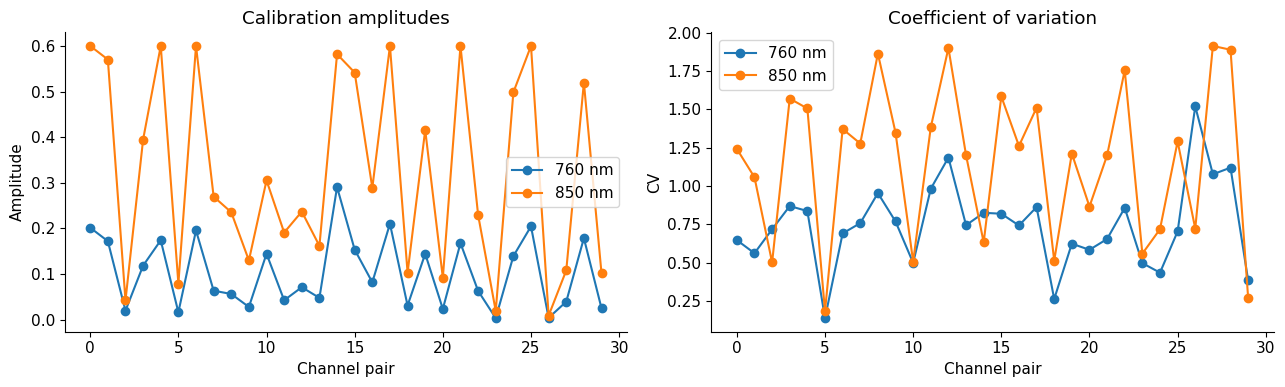

In [ ]:
amps = np.array(cal['amplitudes'])
cv   = np.array(cal['coefficient_of_variation'])
qlev = np.array([q['level'] for q in cal['signal_quality']])
qsat = np.array([q['saturated'] for q in cal['signal_quality']])
qxt  = np.array([q['xtalk'] for q in cal['signal_quality']])

print('Amplitude matrix shape           :', amps.shape)
print('Coefficient-of-variation shape   :', cv.shape)
print('Unique quality levels            :', np.unique(qlev))
print('Any saturated channels?          :', bool(np.any(qsat)))
print('Any cross-talk flagged channels? :', bool(np.any(qxt)))
print('Mean CV per wavelength           :', cv.mean(axis=0))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(amps[:, 0], 'o-', label='760 nm')
ax[0].plot(amps[:, 1], 'o-', label='850 nm')
ax[0].set_title('Calibration amplitudes')
ax[0].set_xlabel('Channel pair')
ax[0].set_ylabel('Amplitude')
ax[0].legend()

ax[1].plot(cv[:, 0], 'o-', label='760 nm')
ax[1].plot(cv[:, 1], 'o-', label='850 nm')
ax[1].set_title('Coefficient of variation')
ax[1].set_xlabel('Channel pair')
ax[1].set_ylabel('CV')
ax[1].legend()
plt.tight_layout()
plt.show()


## 7 · Raw CW signal overview

The `.nirs` file contains the raw CW intensity matrix `d` with shape `(time, channels) = (5290, 60)`. The first 30 columns correspond to wavelength 1 and the next 30 to wavelength 2.


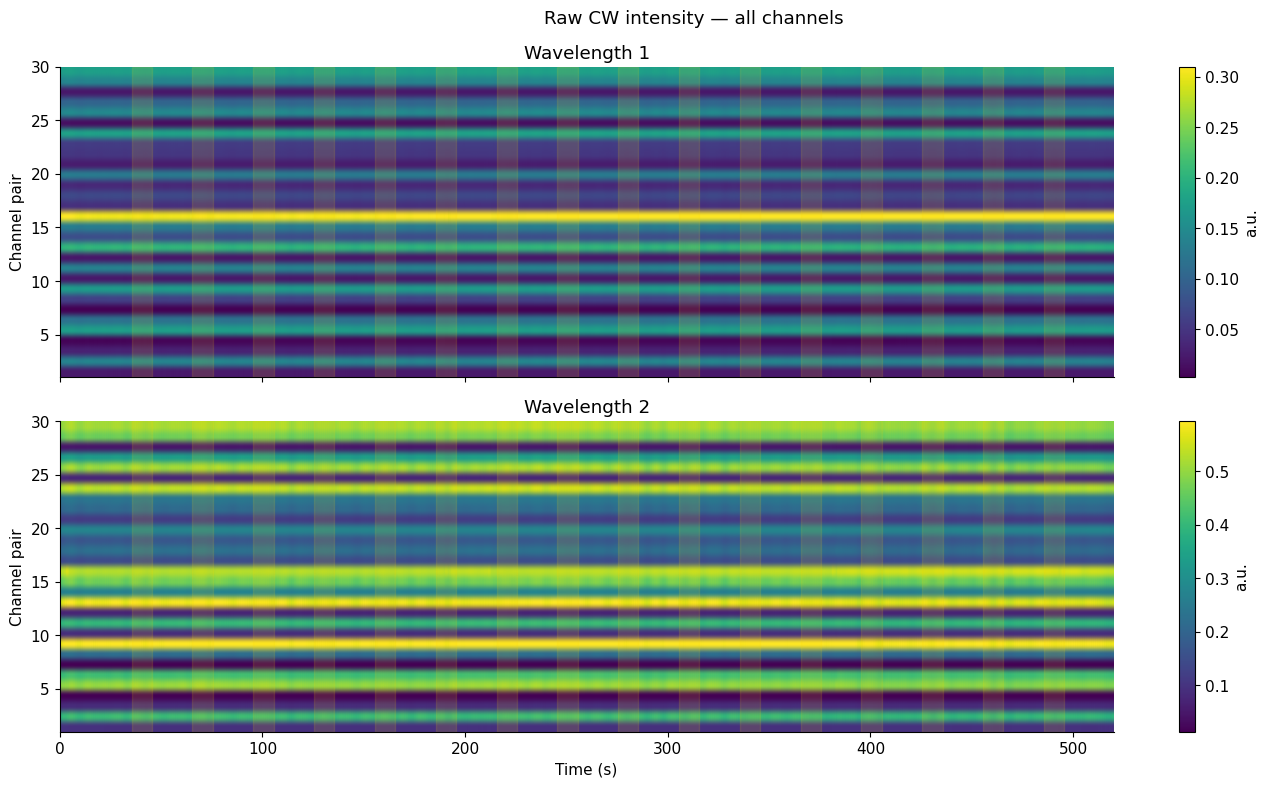

In [ ]:
n_t, n_ch = d.shape
n_pairs = n_ch // 2
wl1 = d[:, :n_pairs]
wl2 = d[:, n_pairs:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Raw CW intensity — all channels')

im0 = axes[0].imshow(wl1.T, aspect='auto', extent=[t[0], t[-1], 1, n_pairs],
                     cmap='viridis', vmin=np.percentile(wl1, 2), vmax=np.percentile(wl1, 98))
axes[0].set_title('Wavelength 1')
axes[0].set_ylabel('Channel pair')
plt.colorbar(im0, ax=axes[0], label='a.u.')

im1 = axes[1].imshow(wl2.T, aspect='auto', extent=[t[0], t[-1], 1, n_pairs],
                     cmap='viridis', vmin=np.percentile(wl2, 2), vmax=np.percentile(wl2, 98))
axes[1].set_title('Wavelength 2')
axes[1].set_ylabel('Channel pair')
axes[1].set_xlabel('Time (s)')
plt.colorbar(im1, ax=axes[1], label='a.u.')

for ax in axes:
    for name, data_ in snirf_stims.items():
        for onset, dur, *_ in data_:
            ax.axvspan(onset, onset+dur, color='gold', alpha=0.12)

plt.tight_layout()
plt.show()


## 8 · Representative channels

This plot helps visually inspect baseline drift, task-related changes, and wavelength agreement in a few channel pairs.


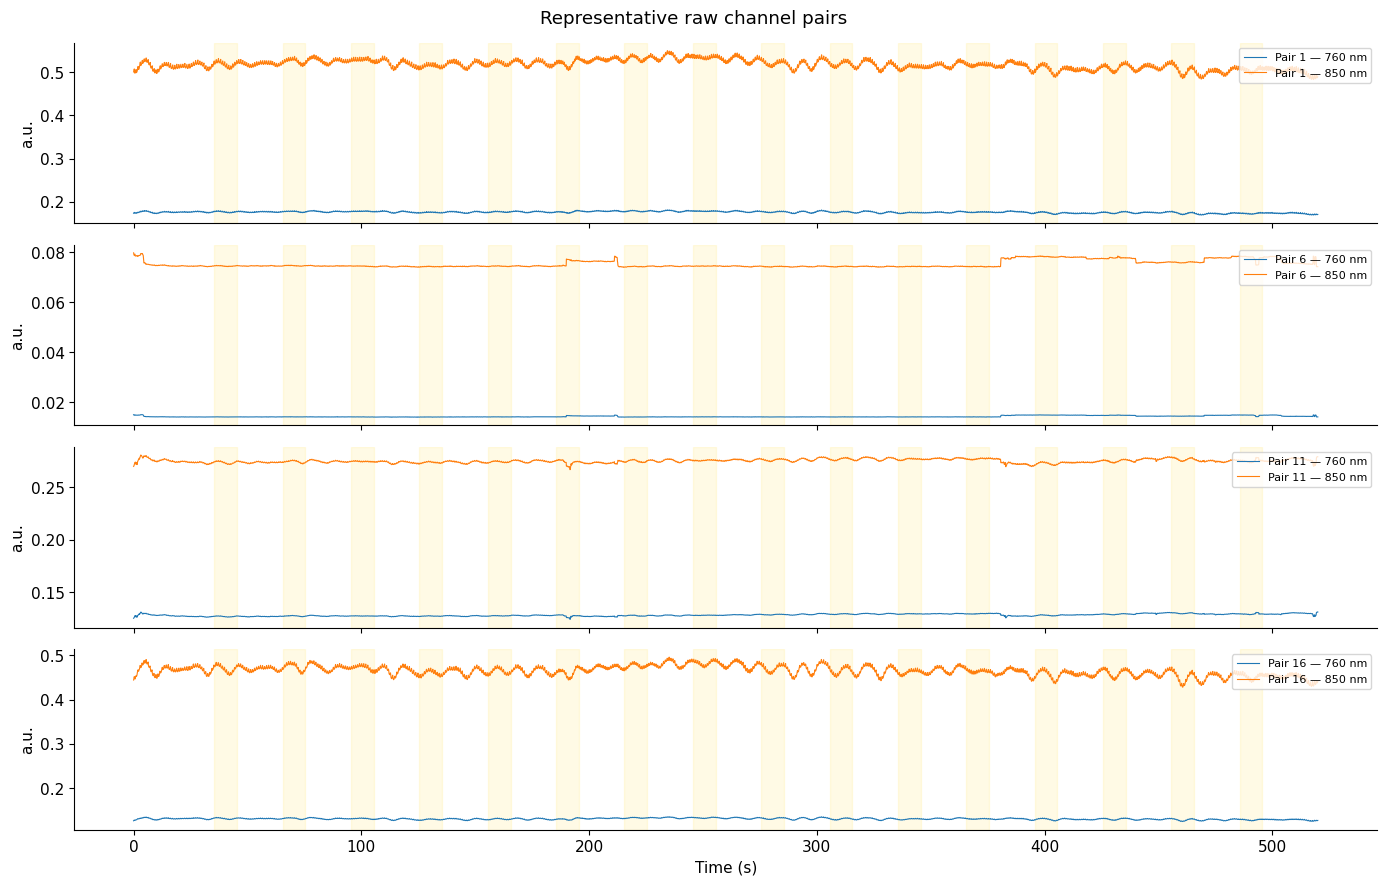

In [ ]:
pairs = [0, 5, 10, 15]
fig, axes = plt.subplots(len(pairs), 1, figsize=(14, 9), sharex=True)
fig.suptitle('Representative raw channel pairs')

for i, ch in enumerate(pairs):
    axes[i].plot(t, d[:, ch], lw=0.8, label=f'Pair {ch+1} — 760 nm')
    axes[i].plot(t, d[:, ch+n_pairs], lw=0.8, label=f'Pair {ch+1} — 850 nm')
    for name, data_ in snirf_stims.items():
        for onset, dur, *_ in data_:
            axes[i].axvspan(onset, onset+dur, color='gold', alpha=0.10)
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].set_ylabel('a.u.')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


## 9 · Probe geometry and ROI grouping

The probe file provides 8 source positions with standard EEG labels (`PPO5h`, `PO9`, `O1`, `POz`, `Iz`, `O2`, `PPO6h`, `PO10`). The companion `ROI_visual_configuration2.mat` defines 6 ROIs: **Left Up / Left Down / Central Up / Central Down / Right Up / Right Down**. The `.mat` file stores a MATLAB MCOS table that scipy cannot parse directly, so we re-derive the same 6-way grouping from the source X/Y coordinates in the probe file.


In [ ]:
# Derive 6 ROIs from the idealized source positions (X = left-right, Y = up-down).
# Left / Central / Right: sign of x (with a small tolerance around midline)
# Up / Down              : y above / below the median source y
X_TOL = 5.0  # mm — anything inside +/-5 mm of x=0 counts as central
src_x = src_pos[:, 0]
src_y = src_pos[:, 1]
y_mid = np.median(src_y)

def _lcr(x):
    if x < -X_TOL: return 'Left'
    if x >  X_TOL: return 'Right'
    return 'Central'

def _ud(y):
    return 'Up' if y >= y_mid else 'Down'

src_roi = {i: f'{_lcr(src_x[i])} {_ud(src_y[i])}' for i in range(len(src_pos))}
roi_labels = np.array([src_roi[s] for s, _ in index_c])
roi_names  = ['Left Up', 'Left Down', 'Central Up', 'Central Down', 'Right Up', 'Right Down']

print('Source label -> ROI')
for i, lab in enumerate(labels_s):
    print(f'  {lab:<6} (x={src_x[i]:>6.1f}, y={src_y[i]:>6.1f})  ->  {src_roi[i]}')
print()
for roi in roi_names:
    chs = [i + 1 for i, r in enumerate(roi_labels) if r == roi]
    print(f'{roi:<14}: {len(chs):>2} channels  {chs}')

# Probe layout plot
fig, ax = plt.subplots(figsize=(9, 7))
palette = {
    'Left Up'     : '#1f77b4',  'Left Down'    : '#9ecae1',
    'Central Up'  : '#2ca02c',  'Central Down' : '#98df8a',
    'Right Up'    : '#d62728',  'Right Down'   : '#ff9896',
}

for i, (s, d_) in enumerate(index_c):
    ax.plot([src_pos[s, 0], det_pos[d_, 0]],
            [src_pos[s, 1], det_pos[d_, 1]],
            color=palette[roi_labels[i]], lw=1.2, alpha=0.55)
    mx = (src_pos[s, 0] + det_pos[d_, 0]) / 2
    my = (src_pos[s, 1] + det_pos[d_, 1]) / 2
    ax.text(mx, my, str(i + 1), fontsize=6, color=palette[roi_labels[i]])

ax.scatter(src_pos[:, 0], src_pos[:, 1], marker='^', s=180, color='darkred', label='Sources')
ax.scatter(det_pos[:, 0], det_pos[:, 1], marker='s', s=80, color='navy', label='Detectors')
for i, (x, y, *_) in enumerate(src_pos):
    ax.text(x + 1, y + 1, str(labels_s[i]), fontsize=8, color='darkred')
for roi in roi_names:
    ax.plot([], [], color=palette[roi], lw=2, label=roi)
ax.axhline(y_mid, color='grey', lw=0.5, ls='--', alpha=0.5)
ax.axvline(0,     color='grey', lw=0.5, ls='--', alpha=0.5)
ax.set_title('Probe layout - 6 ROIs derived from source positions')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.axis('equal')
ax.legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()


## 10 · TD-NIRS `.DAT` inspection

The `.DAT` files store DTOFs for the TD-NIRS probe. The binary layout is inferred from the file rather than hardcoded:

- a variable-length **header** (its length is stored as a `uint32` at byte offset 12),
- followed by a sequence of repetitions, each containing a metadata block (`uint32` words) and a DTOF histogram (`float32`, 4096 bins of 3.05 ps).

The code below reads the header length from the file, derives the number of repetitions, and prints the layout so the assumptions are explicit.

Note that the assignment states *5 repetitions x 4 wavelengths = 20 DTOFs per optode*. The file structure we observe packs ~10 DTOFs per file, which suggests each file covers 5 reps x 2 wavelengths (so each optode placement would have 2 `.DAT` files). Decoding the wavelength index per rep would require documentation of the per-rep metadata block.


In [ ]:
# Parse the DAT header length from the file instead of hardcoding it.
N_BINS  = 4096
PS_BIN  = 3.05

def parse_dat(path, n_bins=N_BINS):
    with open(path, 'rb') as fh:
        raw = fh.read()
    header_len = int(np.frombuffer(raw[12:16], dtype=np.uint32)[0])
    body = raw[header_len:]
    bins_bytes = n_bins * 4
    # body_len = n_reps * (n_meta * 4 + bins_bytes)
    # Scan plausible n_meta values and pick the smallest that divides evenly.
    n_reps = n_meta = rep_bytes = None
    for nm in range(0, 4096):
        rb = nm * 4 + bins_bytes
        if len(body) % rb == 0:
            n_reps, n_meta, rep_bytes = len(body) // rb, nm, rb
            break
    if n_reps is None:
        raise RuntimeError(f'Could not derive rep layout from body size {len(body)}')

    meta = np.zeros((n_reps, n_meta), dtype=np.uint32)
    dtof = np.zeros((n_reps, n_bins), dtype=np.float32)
    for i in range(n_reps):
        off = i * rep_bytes
        meta[i] = np.frombuffer(body[off: off + n_meta * 4], dtype=np.uint32)
        dtof[i] = np.frombuffer(body[off + n_meta * 4: off + rep_bytes], dtype=np.float32)
    return {
        'path': path, 'header_len': header_len,
        'n_reps': n_reps, 'n_meta': n_meta,
        'rep_bytes': rep_bytes, 'meta': meta, 'dtof': dtof,
    }

td = parse_dat(DAT_FILES[0])
print(f'File          : {os.path.basename(td["path"])}')
print(f'Header length : {td["header_len"]} bytes (read from file offset 12)')
print(f'Repetitions   : {td["n_reps"]}')
print(f'Metadata/rep  : {td["n_meta"]} uint32 words')
print(f'DTOF shape    : {td["dtof"].shape}  (float32, {PS_BIN} ps/bin)')

# DTOF plot
bin_ps = np.arange(N_BINS) * PS_BIN
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for i in range(td['n_reps']):
    axes[0].plot(bin_ps, td['dtof'][i], lw=0.8, alpha=0.7, label=f'rep {i+1}')
axes[0].set_yscale('log')
axes[0].set_title(f'DTOF repetitions - {os.path.basename(td["path"])}')
axes[0].set_ylabel('Counts')
axes[0].legend(fontsize=7, ncol=5)

mean_dtof = td['dtof'].mean(axis=0)
std_dtof  = td['dtof'].std(axis=0)
axes[1].plot(bin_ps, mean_dtof, color='navy', lw=1.5)
axes[1].fill_between(bin_ps,
                     np.maximum(mean_dtof - std_dtof, 1e-3),
                     mean_dtof + std_dtof,
                     alpha=0.25, color='navy', label='+/-1 SD')
axes[1].set_yscale('log')
axes[1].set_xlabel('Time (ps)')
axes[1].set_ylabel('Counts')
axes[1].set_title('Mean DTOF +/- 1 SD')
axes[1].legend()
plt.tight_layout()
plt.show()


## 11 · Optical density conversion

The MBLL should be applied to **optical density**, not raw intensity. The standard conversion is:

\[
OD(t) = -\log\left(rac{I(t)}{I_0}
ight)
\]

Here `I0` is taken as the temporal mean of each channel.


In [ ]:
eps = 1e-12
I0 = np.mean(d, axis=0, keepdims=True)
OD = -np.log((d + eps) / (I0 + eps))
print('OD shape:', OD.shape)


## 12 · Band-pass filtering

This cell applies a standard haemodynamic band-pass filter to the optical density data. The default band is 0.01–0.20 Hz, which removes very slow drift and high-frequency noise while preserving the task-related haemodynamic response.


In [ ]:
def bandpass(data, fs, low=0.01, high=0.20, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

OD_filt = bandpass(OD, fs, low=0.01, high=0.20, order=3)
print('Filtered OD shape:', OD_filt.shape)

fig, ax = plt.subplots(figsize=(13, 4))
ch = 10
ax.plot(t, OD[:, ch], alpha=0.5, label='Raw OD')
ax.plot(t, OD_filt[:, ch], lw=1.5, label='Filtered OD')
for name, data_ in snirf_stims.items():
    for onset, dur, *_ in data_:
        ax.axvspan(onset, onset+dur, color='gold', alpha=0.08)
ax.set_title(f'Example optical density trace — channel {ch+1}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('OD')
ax.legend()
plt.tight_layout()
plt.show()


## 13 · MBLL

For each channel pair, the two filtered optical density signals are converted to concentration changes in oxy- and deoxy-haemoglobin using the modified Beer-Lambert law.

Extinction coefficients are taken from the **Prahl (1998)** compilation at the measurement wavelengths (760 / 850 nm).

**DPF = 6.0 is a placeholder.** The per-optode DPF must be computed from the TD-NIRS DTOFs (assignment Q1) and substituted here before drawing quantitative conclusions. A single constant across wavelengths is known to bias the HbO/HbR split.


In [ ]:
# Extinction coefficients in cm^-1 / (mol/L), base-10, from Prahl (1998):
# https://omlc.org/spectra/hemoglobin/summary.html
# Rows: wavelengths [760, 850] nm; Columns: [HbO2, Hb]
E = np.array([
    [1486.5869, 3843.707],   # 760 nm
    [2526.391,  1798.643],   # 850 nm
], dtype=float)

assert wl_list == [760, 850], f'Extinction table mismatch with SD Lambda {wl_list}'

DPF = 6.0                                # placeholder - replace with TD-computed values
rho_cm = dists_mm / 10.0

HbO = np.zeros((len(t), n_pairs))
HbR = np.zeros((len(t), n_pairs))

for i in range(n_pairs):
    delta_od = np.column_stack([OD_filt[:, i], OD_filt[:, i + n_pairs]])
    A = E * (rho_cm[i] * DPF)
    conc = delta_od @ np.linalg.pinv(A).T
    HbO[:, i] = conc[:, 0]
    HbR[:, i] = conc[:, 1]

HbT = HbO + HbR
print('HbO shape:', HbO.shape)
print('HbR shape:', HbR.shape)
print('HbT shape:', HbT.shape)


## 14 · Haemoglobin visualization

This plot shows one representative channel pair after MBLL conversion.


In [ ]:
ch = 10
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t, HbO[:, ch], color='crimson', lw=1.5, label='HbO')
ax.plot(t, HbR[:, ch], color='royalblue', lw=1.5, label='HbR')
ax.plot(t, HbT[:, ch], color='black', lw=1.0, alpha=0.7, label='HbT')
for name, data_ in snirf_stims.items():
    for onset, dur, *_ in data_:
        ax.axvspan(onset, onset+dur, color='gold', alpha=0.08)
ax.set_title(f'MBLL output — channel pair {ch+1}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Δ concentration (a.u.)')
ax.legend()
plt.tight_layout()
plt.show()


## 15 · ROI averages

The next step is usually to average channels within anatomical ROIs. This gives cleaner condition-level responses before block averaging or GLM fitting.


In [ ]:
HbO_roi = {}
HbR_roi = {}
HbT_roi = {}

print('ROI channel counts:')
for roi in roi_names:
    idx = np.where(roi_labels == roi)[0]
    HbO_roi[roi] = HbO[:, idx].mean(axis=1) if len(idx) else np.full(len(t), np.nan)
    HbR_roi[roi] = HbR[:, idx].mean(axis=1) if len(idx) else np.full(len(t), np.nan)
    HbT_roi[roi] = HbT[:, idx].mean(axis=1) if len(idx) else np.full(len(t), np.nan)
    print(f'  {roi:<14}: {len(idx)}')

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
for ax, roi in zip(axes.ravel(), roi_names):
    ax.plot(t, HbO_roi[roi], color='crimson',   label='HbO', lw=1.2)
    ax.plot(t, HbR_roi[roi], color='royalblue', label='HbR', lw=1.2)
    for name, data_ in snirf_stims.items():
        for onset, dur, *_ in data_:
            ax.axvspan(onset, onset + dur, color='gold', alpha=0.08)
    ax.set_title(roi)
    ax.legend(loc='upper right', fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


## 16 · Main conclusions

At this point the notebook has established:

- the CW acquisition contains **60 intensity channels = 30 channel pairs × 2 wavelengths**,
- the experiment contains **4 stimulus conditions** (`1`, `2`, `4`, `8`), with 4 trials each and 10 s duration,
- the probe covers left, central, and right occipital regions,
- all channels passed the calibration quality check,
- optical density, filtered OD, and MBLL haemoglobin signals are computed in-notebook,
- the TD `.DAT` files are required for the per-optode DPF estimate (assignment Q1).

The natural next section after this notebook is:

1. compute DPF per optode from the TD DTOFs and compare to literature,
2. epoch around each stimulus (20 s baseline + 10 s task + 20 s recovery),
3. baseline-correct,
4. average per condition,
5. test for significant differences across tasks.
